# Training the DDPM

This notebook trains the U-Net from notebook 02 to predict noise added by the forward process from notebook 01.

The training objective (Algorithm 1 from the DDPM paper) is remarkably simple: for each clean image $x_0$, pick a random timestep $t$, add the corresponding amount of noise to produce $x_t$, and train the network to recover the noise that was added.

$$
\mathcal{L}(\theta) = \mathbb{E}_{x_0,\, t,\, \epsilon}\left[\, \|\epsilon - \epsilon_\theta(x_t, t)\|^2 \,\right]
$$

This single scalar MSE loss — averaged over a uniform distribution of timesteps — turns out to be all the supervision the model needs.

### What this notebook does

1. Reconstructs the noise schedule and `q_sample` from notebook 01.
2. Reconstructs the U-Net from notebook 02.
3. Trains for 15 epochs on MNIST, logging loss.
4. Saves the trained weights for use in the sampling notebook.
5. Plots the training loss curve.

In [1]:
import math
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torch.optim import Adam
from torchvision import datasets, transforms

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'none'}")

Device: cuda
GPU: Tesla T4


## 1. Noise schedule

Same linear schedule as notebook 01, moved onto the GPU device.

In [2]:
T = 200
beta_start = 1e-4
beta_end = 0.02

betas = torch.linspace(beta_start, beta_end, T, device=device)
alphas = 1.0 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)
sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - alphas_cumprod)

def q_sample(x0, t, noise=None):
    if noise is None:
        noise = torch.randn_like(x0)
    sqrt_alpha           = sqrt_alphas_cumprod[t].view(-1, 1, 1, 1)
    sqrt_one_minus_alpha = sqrt_one_minus_alphas_cumprod[t].view(-1, 1, 1, 1)
    return sqrt_alpha * x0 + sqrt_one_minus_alpha * noise

print(f"T = {T}, schedule on device: {betas.device}")

T = 200, schedule on device: cuda:0


## 2. Model

The U-Net from notebook 02, re-defined here so this notebook is self-contained. (In a later phase we will refactor these classes into `src/model.py` and import them; for now, having everything in one runnable notebook is easier.)

In [4]:
# Clone the repo and import the model from src/model.py
!git clone -q https://github.com/baruahrithik/diffusion-from-scratch.git /tmp/diffusion-from-scratch

import sys
sys.path.insert(0, "/tmp/diffusion-from-scratch")

from src import UNet
print("Imported UNet from src/model.py")

Imported UNet from src/model.py


## 3. Training loop

Standard DDPM training. For each batch we sample random timesteps, construct noisy $x_t$ via the forward process, and train the U-Net to predict the noise.

Hyperparameters:

- Batch size: 128
- Learning rate: 2e-4 (Adam)
- Epochs: 15
- Timesteps: 200

Loss should drop from around 1.0 in the first few steps to under 0.05 by the end. If it stalls above ~0.1 there's likely a bug; if it goes to NaN we have an unstable training run.

In [5]:
batch_size = 128

transform = transforms.Compose([
    transforms.Resize(32),
    transforms.ToTensor(),
    transforms.Lambda(lambda t: (t * 2) - 1),
])
dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=2)

model = UNet(
    in_channels=1,
    base_channels=32,
    channel_mults=(1, 2, 4),
    time_emb_dim=128,
).to(device)

optimizer = Adam(model.parameters(), lr=2e-4)

print(f"Dataset: {len(dataset)} images | Batch size: {batch_size}")
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

100%|██████████| 9.91M/9.91M [00:00<00:00, 59.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.77MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.9MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.48MB/s]

Dataset: 60000 images | Batch size: 128
Model parameters: 1,112,801


In [6]:
epochs = 15
log_every = 100
losses = []

model.train()
for epoch in range(epochs):
    epoch_loss = 0.0
    n_batches = 0
    epoch_start = time.time()
    
    for i, (x0, _) in enumerate(loader):
        x0 = x0.to(device)
        B = x0.shape[0]
        
        # Sample random timesteps for each image in the batch
        t = torch.randint(0, T, (B,), device=device).long()
        
        # Sample noise and construct x_t via forward process
        noise = torch.randn_like(x0)
        x_t = q_sample(x0, t, noise)
        
        # Predict the noise and compute MSE loss
        pred_noise = model(x_t, t)
        loss = F.mse_loss(pred_noise, noise)
        
        # Backprop
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        n_batches += 1
        losses.append(loss.item())
        
        if i % log_every == 0:
            print(f"Epoch {epoch+1:2d}/{epochs} | Step {i:4d}/{len(loader)} | Loss {loss.item():.4f}")
    
    avg = epoch_loss / n_batches
    elapsed = time.time() - epoch_start
    print(f"=== Epoch {epoch+1:2d}/{epochs} done | avg loss {avg:.4f} | time {elapsed:.1f}s ===")

# Save weights to disk so we can reuse them in the sampling notebook
torch.save(model.state_dict(), "ddpm_mnist_weights.pt")
print("\nSaved weights to ddpm_mnist_weights.pt")

Epoch  1/15 | Step    0/469 | Loss 1.0955
Epoch  1/15 | Step  100/469 | Loss 0.1428
Epoch  1/15 | Step  200/469 | Loss 0.0843
Epoch  1/15 | Step  300/469 | Loss 0.0724
Epoch  1/15 | Step  400/469 | Loss 0.0694
=== Epoch  1/15 done | avg loss 0.1144 | time 46.4s ===
Epoch  2/15 | Step    0/469 | Loss 0.0707
Epoch  2/15 | Step  100/469 | Loss 0.0647
Epoch  2/15 | Step  200/469 | Loss 0.0529
Epoch  2/15 | Step  300/469 | Loss 0.0541
Epoch  2/15 | Step  400/469 | Loss 0.0496
=== Epoch  2/15 done | avg loss 0.0550 | time 40.3s ===
Epoch  3/15 | Step    0/469 | Loss 0.0515
Epoch  3/15 | Step  100/469 | Loss 0.0460
Epoch  3/15 | Step  200/469 | Loss 0.0453
Epoch  3/15 | Step  300/469 | Loss 0.0467
Epoch  3/15 | Step  400/469 | Loss 0.0444
=== Epoch  3/15 done | avg loss 0.0477 | time 43.3s ===
Epoch  4/15 | Step    0/469 | Loss 0.0423
Epoch  4/15 | Step  100/469 | Loss 0.0422
Epoch  4/15 | Step  200/469 | Loss 0.0400
Epoch  4/15 | Step  300/469 | Loss 0.0506
Epoch  4/15 | Step  400/469 | Loss

## 4. Training loss

A characteristic DDPM training curve drops fast in the first epoch (the model learns "predict roughly the mean noise"), then descends slowly as it learns to predict noise at different timesteps with varying precision. We plot on a log scale because most of the meaningful variation is in the bottom half.

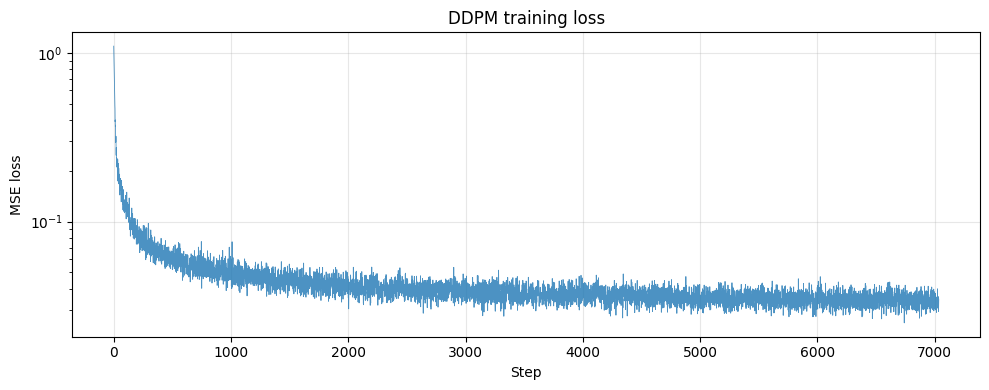

In [7]:
plt.figure(figsize=(10, 4))
plt.plot(losses, linewidth=0.6, alpha=0.8)
plt.xlabel("Step")
plt.ylabel("MSE loss")
plt.title("DDPM training loss")
plt.yscale("log")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("training_loss.png", dpi=100, bbox_inches="tight")
plt.show()